In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
orders=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\orders.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018 00:00


In [3]:
orders.shape

(99441, 8)

In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [5]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [6]:
# change datatype
date_col=['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

for col in date_col:
    orders[col]=pd.to_datetime(orders[col],dayfirst=True,errors='coerce')

In [7]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [8]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [9]:
orders[orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [10]:
orders[(orders['order_status']=='delivered')&(orders['order_delivered_customer_date'].isnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:00,2017-11-28 17:56:00,2017-11-30 18:12:00,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:00,2018-06-20 07:19:00,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:00,2018-07-01 17:15:00,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:00,2018-07-01 22:15:00,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:00,2018-07-01 21:29:00,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:00,2017-05-25 23:30:00,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:00,2018-06-08 12:36:00,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:00,2018-06-27 16:29:00,2018-07-03 19:26:00,NaT,2018-07-19


In [11]:
orders[(orders['order_status']=='delivered')&(orders['order_delivered_customer_date'].isnull())][['order_id','order_purchase_timestamp','order_delivered_carrier_date','order_delivered_customer_date']]
                                                                                                  

,order_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,2017-11-28 17:44:00,2017-11-30 18:12:00,NaT
20618,f5dd62b788049ad9fc0526e3ad11a097,2018-06-20 06:58:00,2018-06-25 08:05:00,NaT
43834,2ebdfc4f15f23b91474edf87475f108e,2018-07-01 17:05:00,2018-07-03 13:57:00,NaT
79263,e69f75a717d64fc5ecdfae42b2e8e086,2018-07-01 22:05:00,2018-07-03 13:57:00,NaT
82868,0d3268bad9b086af767785e3f0fc0133,2018-07-01 21:14:00,2018-07-03 09:28:00,NaT
92643,2d858f451373b04fb5c984a1cc2defaf,2017-05-25 23:22:00,NaT,NaT
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,2018-06-08 12:09:00,2018-06-12 14:10:00,NaT
98038,20edc82cf5400ce95e1afacc25798b31,2018-06-27 16:09:00,2018-07-03 19:26:00,NaT


In [12]:
orders['order_id'].duplicated().sum()

np.int64(0)

In [13]:
order_items=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\order_items.csv')
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
order_items.shape

(112650, 7)

In [15]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [16]:
order_items.duplicated().sum()

np.int64(0)

In [17]:
# change datatype
order_items['shipping_limit_date']=pd.to_datetime(order_items['shipping_limit_date'])

In [18]:
order_items['price'].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [19]:
order_items[order_items['price']<=0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [20]:
order_items[order_items['price']>1000].shape

(844, 7)

In [21]:
order_items[['order_id','product_id','price']].nlargest(10,'price')

,order_id,product_id,price
3556,0812eb902a67711a1cb742b3cdaa65ae,489ae2aa008f021502940f251d4cce7f,6735.00
112233,fefacc66af859508bf1a7934eab1e97f,69c590f7ffc7bf8db97190b6cb6ed62e,6729.00
107841,f5136e38d1a14a4dbd87dff67da82701,1bdf5e6731585cf01aa8169c7028d6ad,6499.00
74336,a96610ab360d42a2e5335a3998b4718a,a6492cc69376c469ab6f61d8f44de961,4799.00
11249,199af31afc78c699f0dbf71fb178d4d4,c3ed642d592594bb648ff4a04cee2747,4690.00
62086,8dbc85d1447242f3b127dda390d56e19,259037a6a41845e455183f89c5035f18,4590.00
29193,426a9742b533fc6fed17d1fd6d143d7e,a1beef8f3992dbd4cd8726796aa69c53,4399.87
45843,68101694e5c5dc7330c91e1bbc36214f,6cdf8fc1d741c76586d8b6b15e9eef30,4099.99
78310,b239ca7cd485940b31882363b52e6674,dd113cb02b2af9c8e5787e8f1f0722f6,4059.00
59137,86c4eab1571921a6a6e248ed312f5a5a,6902c1962dd19d540807d0ab8fade5c6,3999.90


In [22]:
order_items['freight_value'].describe()

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [23]:
order_items[order_items['freight_value']>1000].shape

(0, 7)

In [24]:
order_payments=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\order_payments.csv')
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [25]:
order_payments.shape

(103886, 5)

In [26]:
order_payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [27]:
order_payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [28]:
order_payments[order_payments['payment_type']=='not_defined']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [29]:
order_payments[order_payments['payment_type']=='not_defined'].merge(orders[['order_id','order_status']],
                                                                   on='order_id',how='left')

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_status
0,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0,canceled
1,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0,canceled
2,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0,canceled


In [30]:
order_payments['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [31]:
order_payments[order_payments['payment_installments']<=0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [32]:
order_payments[order_payments['payment_installments']<=0].merge(orders[['order_id','order_status']],
                                                                   on='order_id',how='left')

,order_id,payment_sequential,payment_type,payment_installments,payment_value,order_status
0,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69,delivered
1,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94,delivered


In [33]:
order_payments[order_payments['order_id'].isin(['744bade1fcf9ff3f31d860ace076d422','1a57108394169c0b47d8f876acc9ba2d'])]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [34]:
products=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\products.csv')
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [35]:
products.shape

(32951, 9)

In [36]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


In [37]:
products['product_id'].duplicated().sum()

np.int64(0)

In [38]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [39]:
order_items[order_items['product_id'].isin(products[products['product_category_name'].isnull()]['product_id'])].shape

(1603, 7)

In [40]:
products[
    products['product_weight_g'].isnull() |
    products['product_length_cm'].isnull() |
    products['product_height_cm'].isnull() |
    products['product_width_cm'].isnull()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
order_items[order_items['product_id'].isin(products[
    products['product_weight_g'].isnull() |
    products['product_length_cm'].isnull() |
    products['product_height_cm'].isnull() |
    products['product_width_cm'].isnull()
]['product_id'])]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
7098,101157d4fae1c9fb74a00a5dee265c25,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 08:02:26,29.0,14.52
9233,1521c6bb7b1028154c8c67cf80fa809f,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:10:16,29.0,16.05
28715,415cfaaaa8cea49f934470548797fed1,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
28716,415cfaaaa8cea49f934470548797fed1,2,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
39299,595316a07cd3dea9db7adfcc7e247ae7,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-18 04:26:04,39.0,9.27
48424,6e150190fbe04c642a9cf0b80d83ee16,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-06-30 16:45:14,39.0,16.79
48980,6f497c40431d5fb0cfbd6c943dd29215,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 05:55:32,29.0,10.96
58833,85f8ad45e067abd694b627859fa57453,1,09ff539a621711667c43eba6a3bd8466,8b8cfc8305aa441e4239358c9f6f2485,2017-02-03 21:40:02,1934.0,27.00
71134,a2456e7f02197951664897a94c87242d,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-06 11:50:09,29.0,24.84
73556,a7a43f469c0d7bdb0a23a82db125aefa,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-28 13:15:11,39.0,15.10


In [42]:
order_items[order_items['product_id'].isin(products[
    products['product_weight_g'].isnull() |
    products['product_length_cm'].isnull() |
    products['product_height_cm'].isnull() |
    products['product_width_cm'].isnull()
]['product_id'])]['product_id'].value_counts()

product_id
5eb564652db742ff8f28759cd8d2652a    17
09ff539a621711667c43eba6a3bd8466     1
Name: count, dtype: int64

In [43]:
customers=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\customers.csv')
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [44]:
customers.shape

(99441, 5)

In [45]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [46]:
customers['customer_id'].duplicated().sum()

np.int64(0)

In [47]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [48]:
customers['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [49]:
customers['customer_city'].nunique()

4119

In [50]:
customers['customer_unique_id'].duplicated().sum()

np.int64(3345)

In [51]:
customers['customer_unique_id'].value_counts().head(10)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
dc813062e0fc23409cd255f7f53c7074     6
63cfc61cee11cbe306bff5857d00bfe4     6
f0e310a6839dce9de1638e0fe5ab282a     6
de34b16117594161a6a89c50b289d35a     6
Name: count, dtype: int64

In [52]:
sellers=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\sellers.csv')
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [53]:
sellers.shape

(3095, 4)

In [54]:
sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [55]:
sellers['seller_id'].duplicated().sum()

np.int64(0)

In [56]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [57]:
sellers['seller_state'].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [58]:
sellers['seller_city'].nunique()

611

In [59]:
geolocation=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\geolocation.csv')
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [60]:
geolocation.shape

(1000163, 5)

In [61]:
geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


In [62]:
geolocation.duplicated().sum()

np.int64(261831)

In [63]:
geolocation.drop_duplicates().shape

(738332, 5)

In [64]:
geolocation=geolocation.drop_duplicates().reset_index(drop=True)

In [65]:
geolocation.shape

(738332, 5)

In [66]:
translation=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\product_category_name_translation.csv')
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [67]:
translation.shape

(71, 2)

In [68]:
translation.isnull().sum()
translation.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


In [69]:
translation.drop_duplicates().shape

(71, 2)

In [70]:
translation['product_category_name'].duplicated().sum()

np.int64(0)

In [71]:
# Check which product categories are missing from the translation table
set(products['product_category_name'].dropna())-set(translation['product_category_name'])

{'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}

In [72]:
set(translation['product_category_name'])-set(products['product_category_name'].dropna())

set()

In [73]:
products['product_category_name'].nunique()

73

In [74]:
products['product_category_name'].isnull().sum()

np.int64(610)

In [75]:
products[products['product_category_name'].isnull()]['product_id'].isin(order_items['product_id']).sum()

np.int64(610)

In [76]:
order_items[order_items['product_id'].isin(products[products['product_category_name'].isnull()]['product_id'])].nunique()

order_id               1451
order_item_id             7
product_id              610
seller_id               257
shipping_limit_date    1449
price                   404
freight_value           572
dtype: int64

In [77]:
order_items[order_items['product_id'].isin(products[products['product_category_name'].isnull()]['product_id'])].isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [78]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [79]:
products[products['product_category_name'].isnull()].isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [80]:
products['product_category_name']=products['product_category_name'].fillna('unknown')

In [81]:
products[['product_name_lenght','product_description_lenght','product_photos_qty','product_weight_g',
    'product_length_cm','product_width_cm','product_height_cm']].describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_width_cm,product_height_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,23.196728,16.937661
std,10.245741,635.115225,1.736766,4282.038731,16.914458,12.079047,13.637554
min,5.000000,4.000000,1.000000,0.000000,7.000000,6.000000,2.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,15.000000,8.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,20.000000,13.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,30.000000,21.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,118.000000,105.000000


In [82]:
products[
    products['product_weight_g'].isnull() |
    products['product_length_cm'].isnull() |
    products['product_height_cm'].isnull() |
    products['product_width_cm'].isnull()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN
18851,5eb564652db742ff8f28759cd8d2652a,unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
products['product_weight_g']=products['product_weight_g'].fillna(products['product_weight_g'].mean())

In [84]:
products['product_weight_g'].isnull().sum()

np.int64(0)

In [85]:
products.isnull().sum()

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                0
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [86]:
products[
    products['product_name_lenght'].isnull()
][['product_id', 'product_category_name',
   'product_name_lenght',
   'product_description_lenght',
   'product_photos_qty']]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty
105,a41e356c76fab66334f36de622ecbd3a,unknown,NaN,NaN,NaN
128,d8dee61c2034d6d075997acef1870e9b,unknown,NaN,NaN,NaN
145,56139431d72cd51f19eb9f7dae4d1617,unknown,NaN,NaN,NaN
154,46b48281eb6d663ced748f324108c733,unknown,NaN,NaN,NaN
197,5fb61f482620cb672f5e586bb132eae9,unknown,NaN,NaN,NaN
...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,unknown,NaN,NaN,NaN
32589,10dbe0fbaa2c505123c17fdc34a63c56,unknown,NaN,NaN,NaN
32616,bd2ada37b58ae94cc838b9c0569fecd8,unknown,NaN,NaN,NaN
32772,fa51e914046aab32764c41356b9d4ea4,unknown,NaN,NaN,NaN


In [87]:
products[products['product_name_lenght'].isnull()]['product_id'].isin(order_items['product_id']).sum()

np.int64(610)

In [88]:
reviews=pd.read_csv(r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\order_reviews.csv')
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [89]:
reviews.shape

(99224, 7)

In [90]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


In [91]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [92]:
reviews['review_id'].duplicated().sum()

np.int64(814)

In [93]:
reviews['review_id'].nunique()

98410

In [94]:
reviews[reviews['review_id'].duplicated(keep=False)].sort_values('review_id')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
...,...,...,...,...,...,...,...
31120,fe5c833752953fed3209646f1f63b53c,4863e15fa53273cc7219c58f5ffda4fb,1,NaN,"Comprei dois produtos e ambos, mesmo enviados ...",2018-02-28 00:00:00,2018-02-28 13:57:52
7870,ff2fc9e68f8aabfbe18d710b83aabd30,2da58e0a7dcfa4ce1e00fad9d03ca3b5,2,NaN,NaN,2018-03-17 00:00:00,2018-03-19 11:44:15
82521,ff2fc9e68f8aabfbe18d710b83aabd30,1078d496cc6ab9a8e6f2be77abf5091b,2,NaN,NaN,2018-03-17 00:00:00,2018-03-19 11:44:15
73951,ffb8cff872a625632ac983eb1f88843c,c44883fc2529b4aa03ca90e7e09d95b6,3,NaN,NaN,2017-07-22 00:00:00,2017-07-26 13:41:07


In [95]:
reviews.groupby('review_id').nunique().max(axis=1).value_counts().sort_index()

1    97621
2      764
3       25
Name: count, dtype: int64

In [96]:
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [97]:
reviews['review_score'].max()

np.int64(5)

In [98]:
reviews['review_comment_message'].notnull().sum()

np.int64(40977)

In [99]:
reviews['review_comment_title'].notnull().sum()

np.int64(11568)

In [100]:
reviews['review_creation_date']=pd.to_datetime(reviews['review_creation_date'],format='%Y-%m-%d %H:%M:%S',errors='coerce')
reviews['review_answer_timestamp']=pd.to_datetime(reviews['review_answer_timestamp'],format='%Y-%m-%d %H:%M:%S',errors='coerce')

In [101]:
reviews[['review_creation_date','review_answer_timestamp']].isnull().sum()

review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [102]:
reviews['order_id'].duplicated().sum()

np.int64(551)

In [103]:
reviews.groupby('order_id')['review_score'].nunique().value_counts().sort_index()

review_score
1    98471
2      202
Name: count, dtype: int64

In [104]:
reviews[reviews.groupby('order_id')['review_score'].transform('nunique')>1].sort_values('order_id')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04,2018-03-05 17:02:00
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19,2017-07-20 12:06:11
...,...,...,...,...,...,...,...
91008,67f300be4fddb206e5fad4e8a3bcda0c,fcde2f7449493b4f207a23fae117b0fb,5,NaN,Não tem,2017-06-02,2017-06-03 13:13:32
1157,3c625d52413314975e47e144fbc3cb8e,fd61441ba2a7b57e6342862e779b10b0,5,NaN,NaN,2017-10-04,2017-10-05 18:02:50
86641,24ad2fc85ec000ba4fbfd9841d9a1972,fd61441ba2a7b57e6342862e779b10b0,4,NaN,"Tem que retirar nos correios, muito incômodo",2017-10-14,2017-10-16 21:23:28
27465,5e78482ee783451be6026e5cf0c72de1,ff763b73e473d03c321bcd5a053316e8,3,NaN,Não sei que haverá acontecido os demais chegaram,2017-11-18,2017-11-18 09:02:48


In [105]:
reviews[reviews['review_id'].duplicated(keep=False)].sort_values('review_id')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:53
...,...,...,...,...,...,...,...
31120,fe5c833752953fed3209646f1f63b53c,4863e15fa53273cc7219c58f5ffda4fb,1,NaN,"Comprei dois produtos e ambos, mesmo enviados ...",2018-02-28,2018-02-28 13:57:52
7870,ff2fc9e68f8aabfbe18d710b83aabd30,2da58e0a7dcfa4ce1e00fad9d03ca3b5,2,NaN,NaN,2018-03-17,2018-03-19 11:44:15
82521,ff2fc9e68f8aabfbe18d710b83aabd30,1078d496cc6ab9a8e6f2be77abf5091b,2,NaN,NaN,2018-03-17,2018-03-19 11:44:15
73951,ffb8cff872a625632ac983eb1f88843c,c44883fc2529b4aa03ca90e7e09d95b6,3,NaN,NaN,2017-07-22,2017-07-26 13:41:07


In [106]:
reviews=reviews.drop_duplicates(subset='review_id',keep='first')

In [107]:
reviews['order_id'].duplicated().sum()

np.int64(243)

In [108]:
reviews['order_id'].value_counts().sort_index()

order_id
00010242fe8c5a6d1ba2dd792cb16214    1
00018f77f2f0320c557190d7a144bdd3    1
000229ec398224ef6ca0657da4fc703e    1
00024acbcdf0a6daa1e931b038114c75    1
00042b26cf59d7ce69dfabb4e55b4fd9    1
                                   ..
fffc94f6ce00a00581880bf54a75a037    1
fffcd46ef2263f404302a634eb57f7eb    1
fffce4705a9662cd70adb13d4a31832d    1
fffe18544ffabc95dfada21779c9644f    1
fffe41c64501cc87c801fd61db3f6244    1
Name: count, Length: 98167, dtype: int64

In [109]:
reviews['review_score'].isnull().sum()

np.int64(0)

In [110]:
sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [111]:
sellers['seller_id'].duplicated().sum()

np.int64(0)

In [112]:
sellers['seller_state'].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

In [113]:
geolocation[
    ['geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state']
].duplicated().sum()

np.int64(710420)

In [114]:
geolocation['geolocation_zip_code_prefix'].nunique()

19015

In [115]:
geolocation['geolocation_zip_code_prefix'].min(), geolocation['geolocation_zip_code_prefix'].max()

(np.int64(1001), np.int64(99990))

In [116]:
geolocation[['geolocation_lat', 'geolocation_lng']].describe()

,geolocation_lat,geolocation_lng
count,738332.000000,738332.000000
mean,-20.998353,-46.461098
std,5.892315,4.393705
min,-36.605374,-101.466766
25%,-23.603061,-48.867822
50%,-22.873588,-46.647278
75%,-19.923336,-43.836974
max,45.065933,121.105394


In [117]:
geolocation[
    (geolocation['geolocation_lat'].abs() > 40) |
    (geolocation['geolocation_lng'].abs() > 60)
]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
281789,19274,-10.893066,-61.932123,primavera,SP
355591,28165,41.614052,-8.411675,vila nova de campos,RJ
355600,28145,-8.741506,-63.907933,sao sebastiao de campos,RJ
355694,28155,42.439286,13.820214,santa maria,RJ
358103,28595,43.684961,-7.411080,portela,RJ
...,...,...,...,...,...
627844,83252,42.184003,-8.723762,ilha dos valadares,PR
710355,95130,14.585073,121.105394,santa lucia do piai,RS
732029,98780,-36.605374,-64.283946,santa rosa,RS
732475,98780,-31.418865,-60.336265,santa rosa,RS


In [118]:
(
    (
        (geolocation['geolocation_lat'].abs() > 40) |
        (geolocation['geolocation_lng'].abs() > 60)
    ).sum()
    / len(geolocation) * 100
)

np.float64(0.7236581917077954)

In [119]:
mask=(
    (geolocation['geolocation_lat'].abs() > 40) |
    (geolocation['geolocation_lng'].abs() > 60)
)
geolocation.loc[mask,['geolocation_lat','geolocation_lng']]=np.nan

In [120]:
geolocation[['geolocation_lat','geolocation_lng']].isnull().sum()

geolocation_lat    5343
geolocation_lng    5343
dtype: int64

In [121]:
geolocation.isnull().sum()

geolocation_zip_code_prefix       0
geolocation_lat                5343
geolocation_lng                5343
geolocation_city                  0
geolocation_state                 0
dtype: int64

In [122]:
translation.dtypes

product_category_name            str
product_category_name_english    str
dtype: object

In [123]:
order_items['order_id'].isin(orders['order_id']).all()

np.True_

In [124]:
order_items['product_id'].isin(products['product_id']).all()
order_items['seller_id'].isin(sellers['seller_id']).all()

np.True_

In [125]:
orders['customer_id'].isin(customers['customer_id']).all()

np.True_

In [126]:
order_payments['order_id'].isin(orders['order_id']).all()

np.True_

In [127]:
reviews['order_id'].isin(orders['order_id']).all()

np.True_

In [128]:
orders['customer_id'].duplicated().sum()

np.int64(0)

In [129]:
orders_customers=orders.merge(customers,on='customer_id',how='left')

In [130]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [131]:
sales=orders_customers.merge(order_items,on='order_id',how='inner')

In [132]:
sales[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']].isna().sum()

order_id         0
product_id       0
seller_id        0
price            0
freight_value    0
dtype: int64

In [133]:
sales=sales.merge(products,on='product_id',how='left')

In [134]:
sales=sales.merge(translation,on='product_category_name',how='left')

In [135]:
sales['product_category_name_english'].isna().sum()

np.int64(1627)

In [136]:
sales.loc[
    sales['product_category_name_english'].isna(),
    'product_category_name'
].value_counts()

product_category_name
unknown                                          1603
portateis_cozinha_e_preparadores_de_alimentos      15
pc_gamer                                            9
Name: count, dtype: int64

In [137]:
sales['product_category_name_english'] = sales[
    'product_category_name_english'
].fillna('Unknown')

In [138]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   customer_id                    112650 non-null  str           
 2   order_status                   112650 non-null  str           
 3   order_purchase_timestamp       112650 non-null  datetime64[us]
 4   order_approved_at              112635 non-null  datetime64[us]
 5   order_delivered_carrier_date   111456 non-null  datetime64[us]
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  112650 non-null  datetime64[us]
 8   customer_unique_id             112650 non-null  str           
 9   customer_zip_code_prefix       112650 non-null  int64         
 10  customer_city                  112650 non-null  str           
 11  customer_st

In [139]:
payments_summary=order_payments.groupby('order_id',as_index=False).agg(total_payment_value=('payment_value','sum'))

In [140]:
payments_summary.shape
payments_summary.head()

,order_id,total_payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [141]:
orders.loc[~orders['order_id'].isin(payments_summary['order_id']),['order_id','order_status']]

,order_id,order_status
30710,bfbd0f9bdef84302105ad712db648a6c,delivered


In [142]:
sales.loc[
    sales['order_id'] == 'bfbd0f9bdef84302105ad712db648a6c',
    ['order_id', 'product_id', 'price', 'freight_value','order_item_id']
]

,order_id,product_id,price,freight_value,order_item_id
34802,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,1
34803,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,2
34804,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,3


In [143]:
sales=sales.merge(payments_summary,on='order_id',how='left')

In [144]:
sales['item_total']=sales['price']+sales['freight_value']
sales[['price','freight_value','item_total']].head()

,price,freight_value,item_total
0,29.99,8.72,38.71
1,118.70,22.76,141.46
2,159.90,19.22,179.12
3,45.00,27.20,72.20
4,19.90,8.72,28.62


In [145]:
order_summary=sales.groupby('order_id',as_index=False).agg(order_revenue=('item_total','sum'))
order_summary.shape

(98666, 2)

In [146]:
orders.loc[~orders['order_id'].isin(order_summary['order_id']),'order_status'].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [147]:
order_summary=order_summary.merge(orders[['order_id','order_status']],on='order_id',how='left')

In [148]:
order_summary.isna().sum()

order_id         0
order_revenue    0
order_status     0
dtype: int64

In [149]:
monthly_sales=sales.groupby(sales['order_purchase_timestamp'].dt.to_period('M'))['item_total'].sum().reset_index()

In [150]:
monthly_sales.columns=['month','revenue']
monthly_sales.head()

,month,revenue
0,2016-09,354.75
1,2016-10,56808.84
2,2016-12,19.62
3,2017-01,137188.49
4,2017-02,286280.62


In [151]:
monthly_sales.sort_values('revenue',ascending=False).head(10)

,month,revenue
13,2017-11,1179143.77
18,2018-04,1159698.04
17,2018-03,1155126.82
19,2018-05,1149781.82
15,2018-01,1107301.89
21,2018-07,1058728.03
20,2018-06,1022677.11
22,2018-08,1003308.47
16,2018-02,986908.96
14,2017-12,863547.23


In [152]:
monthly_orders=sales.groupby(sales['order_purchase_timestamp'].dt.to_period('M'))['order_id'].nunique().reset_index()
monthly_orders.columns=['month','orders']

In [153]:
monthly_orders.head()

,month,orders
0,2016-09,3
1,2016-10,308
2,2016-12,1
3,2017-01,789
4,2017-02,1733


In [154]:
monthly_orders.sort_values('orders',ascending=False)

,month,orders
13,2017-11,7451
15,2018-01,7220
17,2018-03,7188
18,2018-04,6934
19,2018-05,6853
16,2018-02,6694
22,2018-08,6452
21,2018-07,6273
20,2018-06,6160
14,2017-12,5624


In [155]:
monthly_sales=monthly_sales.merge(monthly_orders,on='month',how='left')
monthly_sales['average_order_value']=(monthly_sales['revenue']/monthly_sales['orders'])
monthly_sales.head()

,month,revenue,orders,average_order_value
0,2016-09,354.75,3,118.250000
1,2016-10,56808.84,308,184.444286
2,2016-12,19.62,1,19.620000
3,2017-01,137188.49,789,173.876413
4,2017-02,286280.62,1733,165.193664


In [156]:
monthly_sales.sort_values('average_order_value',ascending=False).head(10)

,month,revenue,orders,average_order_value
1,2016-10,56808.84,308,184.444286
3,2017-01,137188.49,789,173.876413
6,2017-04,412422.24,2391,172.489435
11,2017-09,720398.91,4243,169.785272
21,2018-07,1058728.03,6273,168.775391
12,2017-10,769312.37,4568,168.413391
19,2018-05,1149781.82,6853,167.777881
18,2018-04,1159698.04,6934,167.248059
23,2018-09,166.46,1,166.460000
20,2018-06,1022677.11,6160,166.019011


In [157]:
monthly_sales.sort_values('average_order_value',ascending=True).head(10)

,month,revenue,orders,average_order_value
2,2016-12,19.62,1,19.620000
0,2016-09,354.75,3,118.250000
9,2017-07,584971.62,3969,147.385140
16,2018-02,986908.96,6694,147.431873
15,2018-01,1107301.89,7220,153.365913
14,2017-12,863547.23,5624,153.546805
22,2018-08,1003308.47,6452,155.503483
10,2017-08,668204.60,4293,155.649802
8,2017-06,502963.04,3217,156.345365
13,2017-11,1179143.77,7451,158.253090


In [158]:
category_sales=sales.groupby('product_category_name_english')['item_total'].sum().reset_index()
category_sales.columns=['category','revenue']
category_sales.sort_values('revenue',ascending=False).head(10)

,category,revenue
44,health_beauty,1441248.07
71,watches_gifts,1305541.61
8,bed_bath_table,1241681.72
66,sports_leisure,1156656.48
16,computers_accessories,1059272.40
40,furniture_decor,902511.79
50,housewares,778397.77
21,cool_stuff,719329.95
6,auto,685384.32
43,garden_tools,584219.21


In [159]:
category_sales['revenue_share'] = (
    category_sales['revenue']
    / category_sales['revenue'].sum()
    * 100
)

category_sales.sort_values(
    'revenue_share',
    ascending=False
).head(10)

,category,revenue,revenue_share
44,health_beauty,1441248.07,9.096748
71,watches_gifts,1305541.61,8.240207
8,bed_bath_table,1241681.72,7.837142
66,sports_leisure,1156656.48,7.300487
16,computers_accessories,1059272.40,6.685826
40,furniture_decor,902511.79,5.696398
50,housewares,778397.77,4.913025
21,cool_stuff,719329.95,4.540206
6,auto,685384.32,4.325951
43,garden_tools,584219.21,3.687425


In [160]:
category_aov = sales.groupby(
    'product_category_name_english'
).agg(
    revenue=('item_total', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()

category_aov['average_order_value'] = (
    category_aov['revenue'] / category_aov['orders']
)

category_aov.sort_values(
    'average_order_value',
    ascending=False
).head(10)

,product_category_name_english,revenue,orders,average_order_value
15,computers,232799.43,181,1286.184696
65,small_appliances_home_oven_and_coffee,50193.57,75,669.247600
46,home_appliances_2,123917.92,234,529.563761
1,agro_industry_and_commerce,78374.07,182,430.626758
57,musical_instruments,210137.37,628,334.613646
64,small_appliances,206668.83,630,328.045762
35,fixed_telephony,64220.81,217,295.948433
58,office_furniture,342532.65,1273,269.075137
20,construction_tools_safety,44463.62,167,266.249222
39,furniture_bedroom,24661.01,95,259.589579


In [161]:
seller_sales = sales.groupby('seller_id')['item_total'].sum().reset_index()
seller_sales.columns = ['seller_id', 'revenue']

In [162]:
seller_orders = sales.groupby('seller_id')['order_id'].nunique().reset_index()

seller_orders.columns = ['seller_id', 'orders']

seller_orders.sort_values('orders',ascending=False).head(10)

,seller_id,orders
1235,6560211a19b47992c3666cc44a7e94c0,1854
881,4a3ca9315b744ce9f8e9374361493884,1806
2481,cc419e0650a3c5ba77189a1882b7556a,1706
368,1f50f920176fa81dab994f9023523100,1404
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314
1824,955fee9216a65b617aa5c0531780ce60,1287
1505,7a67c85e85bb2ce8582c35f2203ad736,1160
2836,ea8482cd71df3c1969d7b9473ff13abc,1146
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132
731,3d871de0142ce09b7081e2b9d1733cb1,1080


In [163]:
customer_sales=sales.groupby('customer_unique_id')['item_total'].sum().reset_index()
customer_sales.columns=['customer_unique_id','revenue']

customer_sales.sort_values('revenue',ascending=False).head(10)


,customer_unique_id,revenue
3799,0a0a92112bd4c708ca5fde585afaa872,13664.08
81388,da122df9eeddfedc1dc1f5349a1a690c,7571.63
44139,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
82230,dc4802a71eae9be1dd28f5d788ceb526,6929.31
26015,459bef486812aa25204be022145caa62,6922.21
95131,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66
23947,4007669dec559734d6f53e029e360987,6081.54
34820,5d0a2980b292d049061542014e8960bf,4809.44
89056,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34
27242,48e1ac109decbb87765a3eade6854098,4681.78


In [164]:
customer_orders = sales.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'orders']
customer_orders['orders'].value_counts().sort_index()

orders
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

In [165]:
repeat_customer_rate = ((customer_orders['orders'] > 1).sum()/ customer_orders['customer_unique_id'].nunique()* 100)
repeat_customer_rate

np.float64(3.0528191154894153)

In [166]:
customer_value = customer_sales.merge(customer_orders,
    on='customer_unique_id',how='left')

customer_value['average_order_value'] = (customer_value['revenue'] / customer_value['orders'])
customer_value.head()

,customer_unique_id,revenue,orders,average_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89


In [167]:
customer_value.sort_values(
    'revenue',ascending=False).head(10)

,customer_unique_id,revenue,orders,average_order_value
3799,0a0a92112bd4c708ca5fde585afaa872,13664.08,1,13664.080
81388,da122df9eeddfedc1dc1f5349a1a690c,7571.63,2,3785.815
44139,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,1,7274.880
82230,dc4802a71eae9be1dd28f5d788ceb526,6929.31,1,6929.310
26015,459bef486812aa25204be022145caa62,6922.21,1,6922.210
95131,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,1,6726.660
23947,4007669dec559734d6f53e029e360987,6081.54,1,6081.540
34820,5d0a2980b292d049061542014e8960bf,4809.44,1,4809.440
89056,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,1,4764.340
27242,48e1ac109decbb87765a3eade6854098,4681.78,1,4681.780


In [168]:
customer_value['customer_type'] = customer_value['orders'].apply(
    lambda x: 'Repeat' if x > 1 else 'One-time'
)
customer_value.groupby('customer_type').agg(
    customers=('customer_unique_id', 'nunique'),
    revenue=('revenue', 'sum')
).reset_index()

,customer_type,customers,revenue
0,One-time,92507,14939106.99
1,Repeat,2913,904446.25


In [169]:
customer_type_summary = customer_value.groupby('customer_type')['revenue'].sum().reset_index()

customer_type_summary['revenue_share'] = (
    customer_type_summary['revenue']
    / customer_type_summary['revenue'].sum()
    * 100
)

customer_type_summary

,customer_type,revenue,revenue_share
0,One-time,14939106.99,94.291393
1,Repeat,904446.25,5.708607


In [170]:
order_status_summary = orders['order_status'].value_counts().reset_index()
order_status_summary.columns = ['order_status', 'orders']
order_status_summary

,order_status,orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [171]:
order_status_summary['percentage'] = (
    order_status_summary['orders']
    / order_status_summary['orders'].sum()
    * 100
)
order_status_summary

,order_status,orders,percentage
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


In [172]:
sales['delivery_days'] = (
    sales['order_delivered_customer_date']
    - sales['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

sales['delivery_days'].describe()

count    110196.000000
mean         12.472587
std           9.445657
min           0.533333
25%           6.736111
50%          10.184028
75%          15.541146
max         209.628472
Name: delivery_days, dtype: float64

In [173]:
sales['delivery_delay_days'] = (
    sales['order_delivered_customer_date']
    - sales['order_estimated_delivery_date']
).dt.total_seconds() / (24 * 60 * 60)
sales['delivery_delay_days'].describe()

count    110196.000000
mean        -11.333535
std          10.162341
min        -146.016667
25%         -16.321528
50%         -12.047222
75%          -6.477083
max         188.975000
Name: delivery_delay_days, dtype: float64

In [174]:
sales['delivery_status'] = sales['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0
    else ('On Time' if x == 0 else 'Early')
)

sales['delivery_status'].value_counts()

delivery_status
Early    103935
Late       8715
Name: count, dtype: int64

In [175]:
delivery_status_summary = (
    sales['delivery_status']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

delivery_status_summary.columns = ['delivery_status', 'percentage']

delivery_status_summary

,delivery_status,percentage
0,Early,92.263648
1,Late,7.736352


In [176]:
order_delivery = sales[
    ['order_id', 'delivery_days', 'delivery_delay_days', 'delivery_status']
].drop_duplicates('order_id')

order_delivery['delivery_status'].value_counts()

delivery_status
Early    90839
Late      7827
Name: count, dtype: int64

In [177]:
order_delivery['delivery_days'].mean()

np.float64(12.558658903653646)

In [178]:
order_delivery['delivery_days'].median()

np.float64(10.218055555555555)

In [179]:
late_delivery_rate = (
    (order_delivery['delivery_status'] == 'Late').mean() * 100
)

late_delivery_rate

np.float64(7.932823870431557)

In [180]:
monthly_delivery = sales.groupby(
    sales['order_purchase_timestamp'].dt.to_period('M')
).agg(
    orders=('order_id', 'nunique'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum())
).reset_index()

monthly_delivery['late_rate'] = (
    monthly_delivery['late_orders']
    / monthly_delivery['orders']
    * 100
)

monthly_delivery.head()

,order_purchase_timestamp,orders,late_orders,late_rate
0,2016-09,3,3,100.000000
1,2016-10,308,3,0.974026
2,2016-12,1,0,0.000000
3,2017-01,789,26,3.295311
4,2017-02,1733,62,3.577611


In [181]:
monthly_delivery.sort_values(
    'late_rate',
    ascending=False
).head(10)

,order_purchase_timestamp,orders,late_orders,late_rate
0,2016-09,3,3,100.000000
17,2018-03,7188,1641,22.829716
16,2018-02,6694,1184,17.687481
13,2017-11,7451,1172,15.729432
22,2018-08,6452,739,11.453813
19,2018-05,6853,624,9.105501
14,2017-12,5624,506,8.997155
6,2017-04,2391,193,8.071936
15,2018-01,7220,526,7.285319
5,2017-03,2641,163,6.171905


In [182]:
payment_revenue = order_payments.groupby(
    'payment_type'
)['payment_value'].sum().reset_index()

payment_revenue.columns = ['payment_type', 'revenue']

payment_revenue.sort_values(
    'revenue',
    ascending=False
)

,payment_type,revenue
1,credit_card,12542084.19
0,boleto,2869361.27
4,voucher,379436.87
2,debit_card,217989.79
3,not_defined,0.00


In [183]:
payment_revenue['revenue_share'] = (
    payment_revenue['revenue']
    / payment_revenue['revenue'].sum()
    * 100
)

payment_revenue.sort_values(
    'revenue_share',
    ascending=False
)

,payment_type,revenue,revenue_share
1,credit_card,12542084.19,78.344584
0,boleto,2869361.27,17.923569
4,voucher,379436.87,2.370166
2,debit_card,217989.79,1.361681
3,not_defined,0.00,0.000000


In [184]:
payment_orders = order_payments.groupby(
    'payment_type'
)['order_id'].nunique().reset_index()

payment_orders.columns = ['payment_type', 'orders']

payment_orders.sort_values(
    'orders',
    ascending=False
)

,payment_type,orders
1,credit_card,76505
0,boleto,19784
4,voucher,3866
2,debit_card,1528
3,not_defined,3


In [185]:
payment_orders['order_share'] = (
    payment_orders['orders']
    / payment_orders['orders'].sum()
    * 100
)

payment_orders.sort_values(
    'order_share',
    ascending=False
)

,payment_type,orders,order_share
1,credit_card,76505,75.236512
0,boleto,19784,19.455972
4,voucher,3866,3.801900
2,debit_card,1528,1.502665
3,not_defined,3,0.002950


In [186]:
installment_summary = order_payments[
    order_payments['payment_type'] == 'credit_card'
].groupby(
    'payment_installments'
)['order_id'].nunique().reset_index()

installment_summary.columns = ['installments', 'orders']

installment_summary.sort_values(
    'orders',
    ascending=False
).head(10)

,installments,orders
1,1,25407
2,2,12389
3,3,10443
4,4,7088
10,10,5315
5,5,5234
8,8,4253
6,6,3916
7,7,1623
9,9,644


In [187]:
review_score_summary = reviews['review_score'].value_counts().sort_index().reset_index()

review_score_summary.columns = ['review_score', 'reviews']

review_score_summary

,review_score,reviews
0,1,11282
1,2,3114
2,3,8097
3,4,19007
4,5,56910


In [188]:
reviews['review_score'].mean()

np.float64(4.088801951021238)

In [189]:
positive_review_rate = (
    reviews['review_score'].isin([4, 5]).mean() * 100
)

positive_review_rate

np.float64(77.14358296921044)

In [190]:
review_delivery = sales[
    ['order_id', 'delivery_status']
].drop_duplicates('order_id').merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

review_delivery.groupby('delivery_status')['review_score'].mean()

delivery_status
Early    4.237396
Late     2.565309
Name: review_score, dtype: float64

In [191]:
state_sales = sales.groupby(
    'customer_state'
)['item_total'].sum().reset_index()

state_sales.columns = ['state', 'revenue']

state_sales.sort_values(
    'revenue',
    ascending=False
).head(10)

,state,revenue
25,SP,5921678.12
18,RJ,2129681.98
10,MG,1856161.49
22,RS,885826.76
17,PR,800935.44
4,BA,611506.67
23,SC,610213.60
6,DF,353229.44
8,GO,347706.93
7,ES,324801.91


In [192]:
state_orders = sales.groupby(
    'customer_state'
)['order_id'].nunique().reset_index()

state_orders.columns = ['state', 'orders']

state_orders.sort_values(
    'orders',
    ascending=False
).head(10)

,state,orders
25,SP,41375
18,RJ,12762
10,MG,11544
22,RS,5432
17,PR,4998
23,SC,3612
4,BA,3358
6,DF,2125
7,ES,2025
8,GO,2007


In [193]:
state_aov = state_sales.merge(
    state_orders,
    on='state',
    how='left'
)

state_aov['average_order_value'] = (
    state_aov['revenue'] / state_aov['orders']
)

state_aov.sort_values(
    'average_order_value',
    ascending=False
).head(10)

,state,revenue,orders,average_order_value
14,PB,140987.81,532,265.014680
0,AC,19669.70,81,242.835802
3,AP,16262.80,68,239.158824
1,AL,96229.40,411,234.134793
20,RO,57558.02,247,233.028421
13,PA,217647.11,970,224.378464
26,TO,61354.42,279,219.908315
16,PI,108132.28,493,219.335254
21,RR,10064.62,46,218.796087
24,SE,73032.32,345,211.687884


In [194]:
state_flow = sales.groupby(
    ['seller_id', 'customer_state']
).agg(
    orders=('order_id', 'nunique'),
    revenue=('item_total', 'sum')
).reset_index()

state_flow.sort_values(
    'revenue',
    ascending=False
).head(10)

,seller_id,customer_state,orders,revenue
5106,4a3ca9315b744ce9f8e9374361493884,SP,814,99736.23
5000,4869f7a5dfa277a7dca6462dcf3b52b2,SP,449,94411.79
14999,da8622b14eb17ae2831f4ac5b9dab84a,SP,717,89179.48
8760,7c67e1448b00f6e969d365cea6b010ab,SP,392,87763.13
17194,fa1c13f2614d7b5c4749cbc52fecda94,SP,208,80277.76
10538,955fee9216a65b617aa5c0531780ce60,SP,640,71089.33
7054,6560211a19b47992c3666cc44a7e94c0,SP,814,59047.62
5781,53243585a1d6dc2643021fd1853d8905,SP,86,58926.31
8954,7e93a43ef30c4f03f38b393420bc753a,SP,115,58909.97
1228,1025f0e2d44d7041d6cf58b6550e0bfa,SP,322,53210.04


In [195]:
category_financials = sales.groupby(
    'product_category_name_english'
).agg(
    product_revenue=('price', 'sum'),
    freight_revenue=('freight_value', 'sum')
).reset_index()

category_financials['total_value'] = (
    category_financials['product_revenue']
    + category_financials['freight_revenue']
)

category_financials.sort_values(
    'total_value',
    ascending=False
).head(10)

,product_category_name_english,product_revenue,freight_revenue,total_value
44,health_beauty,1258681.34,182566.73,1441248.07
71,watches_gifts,1205005.68,100535.93,1305541.61
8,bed_bath_table,1036988.68,204693.04,1241681.72
66,sports_leisure,988048.97,168607.51,1156656.48
16,computers_accessories,911954.32,147318.08,1059272.40
40,furniture_decor,729762.49,172749.30,902511.79
50,housewares,632248.66,146149.11,778397.77
21,cool_stuff,635290.85,84039.10,719329.95
6,auto,592720.11,92664.21,685384.32
43,garden_tools,485256.46,98962.75,584219.21


In [196]:
payment_check = sales.groupby('order_id', as_index=False).agg(
    sales_value=('item_total', 'sum'),
    payment_value=('total_payment_value', 'first')
)

payment_check['difference'] = (
    payment_check['sales_value']
    - payment_check['payment_value']
)

payment_check['difference'].describe()

count    98665.000000
mean        -0.029092
std          1.129221
min       -182.810000
25%          0.000000
50%          0.000000
75%          0.000000
max         51.620000
Name: difference, dtype: float64

In [197]:
(payment_check['difference'] != 0).sum()

np.int64(19738)

In [198]:
payment_check.loc[
    payment_check['difference'] != 0,
    'difference'
].abs().describe()

count    1.973700e+04
mean     1.657775e-01
std      2.520202e+00
min      1.776357e-15
25%      7.105427e-15
50%      1.421085e-14
75%      2.842171e-14
max      1.828100e+02
Name: difference, dtype: float64

In [199]:
(payment_check['difference'].abs() > 0.01).sum()

np.int64(378)

In [200]:
payment_check.loc[
    payment_check['difference'].abs() > 0.01
].sort_values(
    'difference',
    key=lambda x: x.abs(),
    ascending=False
).head(10)

,order_id,sales_value,payment_value,difference
79538,ce6d150fb29ada17d2082f4847107665,1403.66,1586.47,-182.81
42515,6e5fe7366a2e1bfbf3257dba0af1267f,287.91,406.92,-119.01
43434,70b742795bc441e94a44a084b6d9ce7a,466.93,578.82,-111.89
58752,996c7e73600ad3723e8627ab7bef81e4,587.90,664.43,-76.53
43437,70b7e94ea46d3e8b5bc12a50186edaf0,213.15,274.84,-61.69
72496,bc2c82b0ef78d2252b6176d1972db7c9,242.01,303.02,-61.01
67466,af9ffff2ce6b3defd34fd4c78857a379,413.17,466.97,-53.80
14628,262118ce178bb3e4590a3adcf6d62e6b,177.74,126.12,51.62
73900,bfdb5bbb06458d600a33d61f5f287472,348.93,394.36,-45.43
54305,8d9c0dc8d5a2ce804f6b925d8f8e6c1d,254.45,293.89,-39.44


In [201]:
order_payments[
    order_payments['order_id'] == 'ce6d150fb29ada17d2082f4847107665'
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
359,ce6d150fb29ada17d2082f4847107665,1,credit_card,10,1586.47


In [202]:
sales.loc[
    sales['order_id'] == 'ce6d150fb29ada17d2082f4847107665',
    ['order_id', 'order_item_id', 'product_id', 'price', 'freight_value', 'item_total']
]

,order_id,order_item_id,product_id,price,freight_value,item_total
13268,ce6d150fb29ada17d2082f4847107665,1,638bbb2a5e4f360b71f332ddfebfd672,1299.0,104.66,1403.66


In [203]:
orders.loc[
    orders['order_id'] == 'ce6d150fb29ada17d2082f4847107665'
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
11791,ce6d150fb29ada17d2082f4847107665,d8acb46c718975948423dbf1b603b959,delivered,2018-01-25 11:17:00,2018-01-27 12:35:00,2018-01-29 18:32:00,2018-02-21 17:38:00,2018-03-08


In [204]:
mismatch_rate = (
    (payment_check['difference'].abs() > 0.01).mean() * 100
)

mismatch_rate

np.float64(0.3831106966938966)

In [205]:
total_revenue = sales['item_total'].sum()

total_revenue

np.float64(15843553.24)

In [206]:
total_orders = sales['order_id'].nunique()

total_orders

98666

In [207]:
overall_aov = total_revenue / total_orders

overall_aov

np.float64(160.57763809214927)

In [208]:
total_freight = sales['freight_value'].sum()

total_freight

np.float64(2251909.54)

In [209]:
freight_percentage = (
    total_freight / total_revenue * 100
)

freight_percentage

np.float64(14.213412268623147)

In [210]:
total_product_revenue = sales['price'].sum()

total_product_revenue

np.float64(13591643.700000001)

In [211]:
total_product_revenue + total_freight == total_revenue

np.False_

In [212]:
(total_product_revenue + total_freight) - total_revenue

np.float64(1.862645149230957e-09)

In [213]:
product_revenue_percentage = (
    total_product_revenue / total_revenue * 100
)

product_revenue_percentage

np.float64(85.78658773137687)

In [214]:
total_customers = sales['customer_unique_id'].nunique()

total_customers

95420

In [215]:
revenue_per_customer = total_revenue / total_customers

revenue_per_customer

np.float64(166.04017229092435)

In [216]:
total_sellers = sales['seller_id'].nunique()

total_sellers

3095

In [217]:
total_categories = sales['product_category_name_english'].nunique()

total_categories

72

In [218]:
total_products_sold = sales['product_id'].nunique()

total_products_sold

32951

In [219]:
total_items_sold = sales['order_item_id'].count()

total_items_sold

np.int64(112650)

In [220]:
top_products = sales.groupby(
    'product_id'
)['item_total'].sum().reset_index()

top_products.columns = ['product_id', 'revenue']

top_products.sort_values(
    'revenue',
    ascending=False
).head(10)

,product_id,revenue
24086,bb50f2e236e5eea0100680137654686c,67606.10
27039,d1c427060a0f73f6b889a5c7c61f2ac4,60976.03
14068,6cdd53843498f92890544667809f1595,59093.99
19742,99a4788cb24856965c36a24e339b6058,51071.60
27613,d6160fb7873f184099d9bc95e30376af,50326.18
8051,3dd2a17168ec895c781a9191c1e95ad7,48212.22
22112,aca2eb7d00ea1a7b8ebd4e68314663af,44820.76
12351,5f504b3a1c75b73d6151be81eb05bdc9,41725.81
4996,25c38557cf793876c5abdd5931f922db,40311.95
10867,53b36df67ebb7c41585e8d54d6772e08,39957.93


In [221]:
top_products_qty = sales.groupby(
    'product_id'
)['order_item_id'].count().reset_index()

top_products_qty.columns = ['product_id', 'items_sold']

top_products_qty.sort_values(
    'items_sold',
    ascending=False
).head(10)

,product_id,items_sold
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527
19742,99a4788cb24856965c36a24e339b6058,488
8613,422879e10f46682990de24d770e7f83d,484
7364,389d119b48cf3043d311335e499d9c6b,392
7079,368c6c730842d78016ad823897a372db,388
10840,53759a2ecddad2bb87a079a1f1519f73,373
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343
10867,53b36df67ebb7c41585e8d54d6772e08,323
2794,154e7e31ebfa092203795c972e5804a6,281
8051,3dd2a17168ec895c781a9191c1e95ad7,274


In [222]:
city_sales = sales.groupby(
    'customer_city'
)['item_total'].sum().reset_index()

city_sales.columns = ['city', 'revenue']

city_sales.sort_values(
    'revenue',
    ascending=False
).head(10)

,city,revenue
3588,sao paulo,2170227.12
3147,rio de janeiro,1154234.02
452,belo horizonte,416733.39
557,brasilia,352305.14
1141,curitiba,244739.87
2956,porto alegre,224064.09
3239,salvador,216772.40
705,campinas,212541.70
1526,guarulhos,163575.82
2455,niteroi,137919.38


In [223]:
city_sales['revenue_share'] = (
    city_sales['revenue']
    / city_sales['revenue'].sum()
    * 100
)

city_sales.sort_values(
    'revenue_share',
    ascending=False
).head(10)

,city,revenue,revenue_share
3588,sao paulo,2170227.12,13.697856
3147,rio de janeiro,1154234.02,7.285197
452,belo horizonte,416733.39,2.630303
557,brasilia,352305.14,2.223650
1141,curitiba,244739.87,1.544728
2956,porto alegre,224064.09,1.414229
3239,salvador,216772.40,1.368206
705,campinas,212541.70,1.341503
1526,guarulhos,163575.82,1.032444
2455,niteroi,137919.38,0.870508


In [224]:
category_reviews = sales[
    ['order_id', 'product_category_name_english']
].drop_duplicates().merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

category_reviews = category_reviews.groupby(
    'product_category_name_english'
).agg(
    reviews=('review_score', 'count'),
    average_rating=('review_score', 'mean')
).reset_index()

category_reviews.columns = ['category', 'reviews', 'average_rating']

category_reviews.sort_values(
    'average_rating',
    ascending=True
).head(10)

,category,reviews,average_rating
62,security_and_services,2,2.500000
58,office_furniture,1258,3.619237
31,fashion_male_clothing,110,3.700000
28,fashio_female_clothing,40,3.725000
24,diapers_and_hygiene,27,3.740741
47,home_comfort_2,23,3.826087
42,furniture_mattress_and_upholstery,35,3.828571
5,audio,347,3.835735
20,construction_tools_safety,166,3.849398
48,home_confort,396,3.873737


In [225]:
category_analysis = category_financials.merge(
    category_reviews,
    left_on='product_category_name_english',
    right_on='category',
    how='inner'
)

category_analysis[
    category_analysis['reviews'] >= 100
].sort_values(
    'average_rating',
    ascending=True
).head(10)

,product_category_name_english,product_revenue,freight_revenue,total_value,category,reviews,average_rating
58,office_furniture,273960.70,68571.95,342532.65,office_furniture,1258,3.619237
31,fashion_male_clothing,10797.82,2152.41,12950.23,fashion_male_clothing,110,3.700000
5,audio,50688.50,5710.44,56398.94,audio,347,3.835735
20,construction_tools_safety,40544.52,3919.10,44463.62,construction_tools_safety,166,3.849398
48,home_confort,58572.04,8501.23,67073.27,home_confort,396,3.873737
35,fixed_telephony,59583.00,4637.81,64220.81,fixed_telephony,215,3.902326
0,Unknown,185049.76,28613.14,213662.90,Unknown,1463,3.903623
34,fashion_underwear_beach,9541.55,1916.19,11457.74,fashion_underwear_beach,117,3.940171
49,home_construction,83088.12,13832.24,96920.36,home_construction,484,3.966942
8,bed_bath_table,1036988.68,204693.04,1241681.72,bed_bath_table,9273,3.973148


In [226]:
seller_revenue = sales.groupby(
    'seller_id'
)['item_total'].sum().reset_index()

seller_revenue.columns = ['seller_id', 'revenue']

seller_revenue.sort_values(
    'revenue',
    ascending=False
).head(10)

,seller_id,revenue
857,4869f7a5dfa277a7dca6462dcf3b52b2,249640.70
1535,7c67e1448b00f6e969d365cea6b010ab,239536.44
1013,53243585a1d6dc2643021fd1853d8905,235856.68
881,4a3ca9315b744ce9f8e9374361493884,235539.96
3024,fa1c13f2614d7b5c4749cbc52fecda94,204084.73
2643,da8622b14eb17ae2831f4ac5b9dab84a,185192.32
1560,7e93a43ef30c4f03f38b393420bc753a,182754.05
192,1025f0e2d44d7041d6cf58b6550e0bfa,172860.69
1505,7a67c85e85bb2ce8582c35f2203ad736,162648.38
1824,955fee9216a65b617aa5c0531780ce60,160602.68


In [227]:
payment_reviews = order_payments[
    ['order_id', 'payment_type']
].drop_duplicates().merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

payment_reviews.groupby('payment_type')['review_score'].mean().sort_values()

payment_type
not_defined    1.666667
voucher        4.029706
boleto         4.088687
credit_card    4.089857
debit_card     4.170395
Name: review_score, dtype: float64

In [228]:
category_reviews.sort_values(
    'average_rating',
    ascending=True
).head(10)

,category,reviews,average_rating
62,security_and_services,2,2.500000
58,office_furniture,1258,3.619237
31,fashion_male_clothing,110,3.700000
28,fashio_female_clothing,40,3.725000
24,diapers_and_hygiene,27,3.740741
47,home_comfort_2,23,3.826087
42,furniture_mattress_and_upholstery,35,3.828571
5,audio,347,3.835735
20,construction_tools_safety,166,3.849398
48,home_confort,396,3.873737


In [229]:
category_reviews[
    category_reviews['reviews'] >= 100
].sort_values(
    'average_rating',
    ascending=True
).head(10)

,category,reviews,average_rating
58,office_furniture,1258,3.619237
31,fashion_male_clothing,110,3.700000
5,audio,347,3.835735
20,construction_tools_safety,166,3.849398
48,home_confort,396,3.873737
35,fixed_telephony,215,3.902326
0,Unknown,1463,3.903623
34,fashion_underwear_beach,117,3.940171
49,home_construction,484,3.966942
8,bed_bath_table,9273,3.973148


In [230]:
category_analysis[
    category_analysis['reviews'] >= 100
].sort_values(
    ['total_value', 'average_rating'],
    ascending=[False, True]
).head(10)

,product_category_name_english,product_revenue,freight_revenue,total_value,category,reviews,average_rating
44,health_beauty,1258681.34,182566.73,1441248.07,health_beauty,8752,4.181330
71,watches_gifts,1205005.68,100535.93,1305541.61,watches_gifts,5575,4.066188
8,bed_bath_table,1036988.68,204693.04,1241681.72,bed_bath_table,9273,3.973148
66,sports_leisure,988048.97,168607.51,1156656.48,sports_leisure,7642,4.169720
16,computers_accessories,911954.32,147318.08,1059272.40,computers_accessories,6626,4.031090
40,furniture_decor,729762.49,172749.30,902511.79,furniture_decor,6368,4.014918
50,housewares,632248.66,146149.11,778397.77,housewares,5835,4.144302
21,cool_stuff,635290.85,84039.10,719329.95,cool_stuff,3600,4.171111
6,auto,592720.11,92664.21,685384.32,auto,3873,4.091402
43,garden_tools,485256.46,98962.75,584219.21,garden_tools,3497,4.133829


In [231]:
review_delivery = sales[
    ['order_id', 'delivery_delay_days']
].drop_duplicates('order_id').merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

review_delivery[['delivery_delay_days', 'review_score']].corr()

,delivery_delay_days,review_score
delivery_delay_days,1.000000,-0.266972
review_score,-0.266972,1.000000


In [232]:
review_delivery.groupby(
    review_delivery['delivery_delay_days'] > 0
)['review_score'].mean()

delivery_delay_days
False    4.237396
True     2.565309
Name: review_score, dtype: float64

In [233]:
review_delivery['delivery_status'] = review_delivery['delivery_delay_days'].apply(
    lambda x: 'Late' if x > 0 else 'Early'
)

review_delivery.groupby('delivery_status')['review_score'].mean()

delivery_status
Early    4.237396
Late     2.565309
Name: review_score, dtype: float64

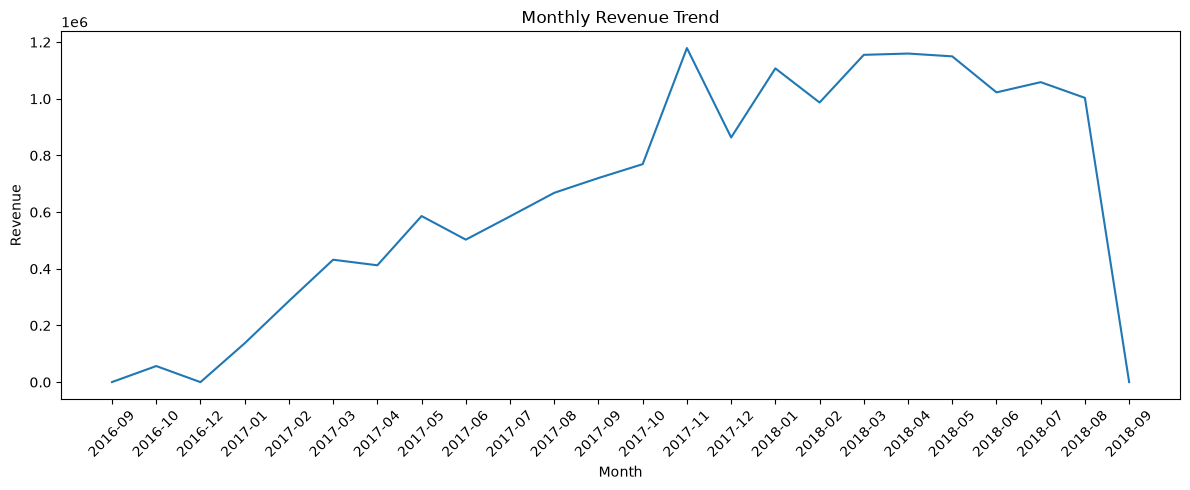

In [234]:
# matplot
monthly_revenue=sales.groupby(sales['order_purchase_timestamp'].dt.to_period('M'))['item_total'].sum()
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_revenue.index.astype(str),y=monthly_revenue.values)

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

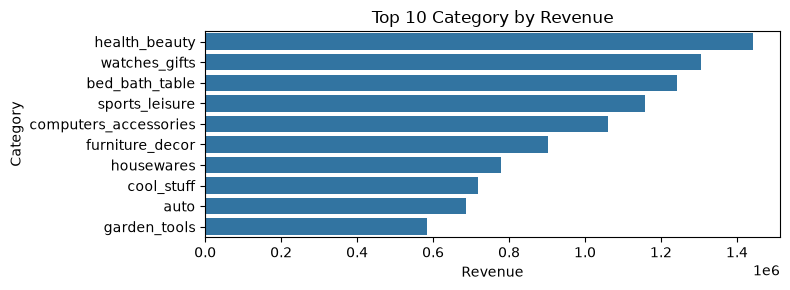

In [235]:
plt.figure(figsize=(8,3))
top_categories=category_sales.sort_values('revenue',ascending=False).head(10)

sns.barplot(data=top_categories,x='revenue',y='category')
plt.title('Top 10 Category by Revenue')
plt.ylabel('Category')
plt.xlabel('Revenue')
plt.tight_layout()

plt.show()

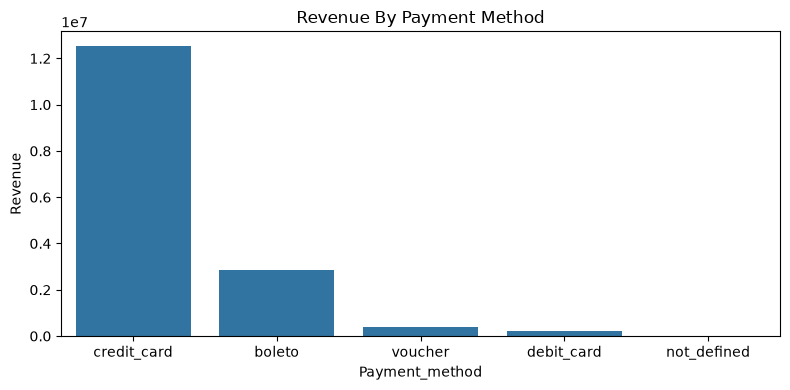

In [236]:
plt.figure(figsize=(8,4))
payment_chart=payment_revenue.sort_values('revenue',ascending=False).head(10)

sns.barplot(data=payment_chart,x='payment_type',y='revenue')

plt.title('Revenue By Payment Method')
plt.ylabel('Revenue')
plt.xlabel('Payment_method')
plt.tight_layout()

plt.show()

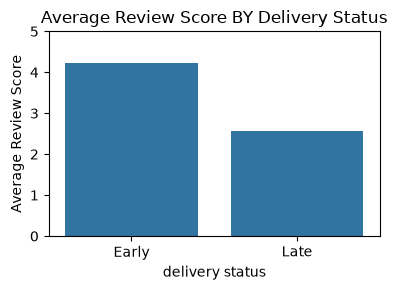

In [237]:
plt.figure(figsize=(4,3))
rating_by_delivery=review_delivery.groupby('delivery_status')['review_score'].mean().reset_index()

sns.barplot(data=rating_by_delivery,x='delivery_status',y='review_score')

plt.title('Average Review Score BY Delivery Status')
plt.ylabel('Average Review Score')
plt.xlabel('delivery status')
plt.tight_layout()
plt.ylim(0,5)
plt.show()

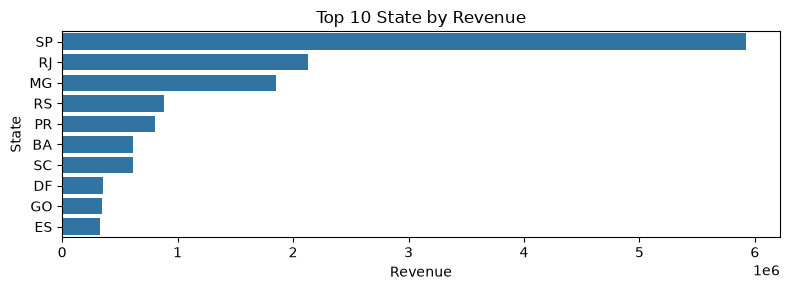

In [238]:
plt.figure(figsize=(8,3))
top_states=state_sales.sort_values('revenue',ascending=False).head(10)

sns.barplot(data=top_states,x='revenue',y='state')
plt.title('Top 10 State by Revenue')
plt.ylabel('State')
plt.xlabel('Revenue')
plt.tight_layout()

plt.show()

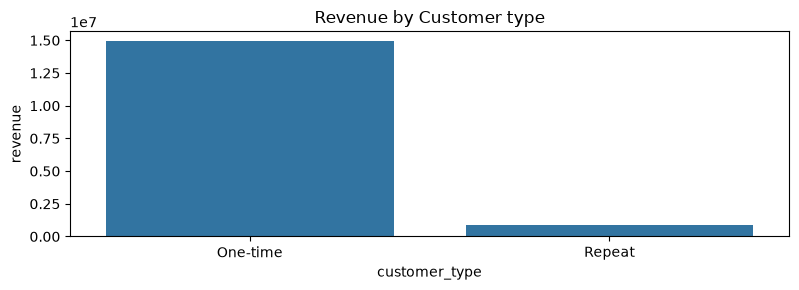

In [239]:
plt.figure(figsize=(8,3))

sns.barplot(data=customer_type_summary,x='customer_type',y='revenue')
plt.title('Revenue by Customer type')
plt.ylabel('revenue')
plt.xlabel('customer_type')
plt.tight_layout()

plt.show()

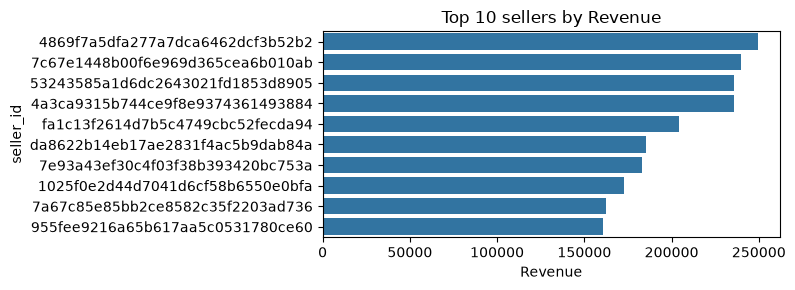

In [240]:
plt.figure(figsize=(8,3))
top_sellers=seller_revenue.sort_values('revenue',ascending=False).head(10)

sns.barplot(data=top_sellers,x='revenue',y='seller_id')
plt.title('Top 10 sellers by Revenue')
plt.ylabel('seller_id')
plt.xlabel('Revenue')
plt.tight_layout()

plt.show()

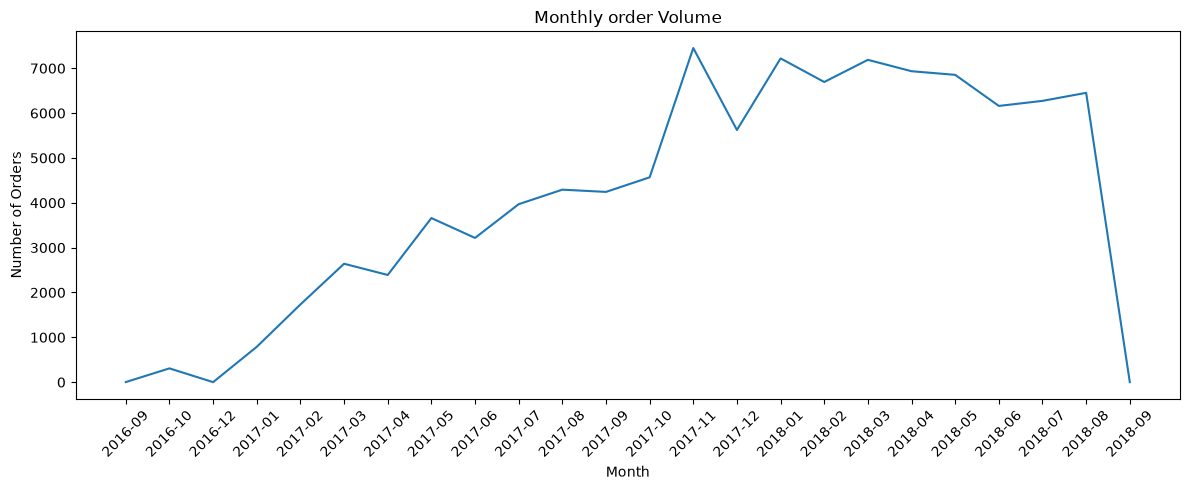

In [241]:
monthly_orders_chart=sales.groupby(sales['order_purchase_timestamp'].dt.to_period('M'))['order_id'].nunique()
plt.figure(figsize=(12,5))
sns.lineplot(x=monthly_orders_chart.index.astype(str),y=monthly_orders_chart.values)

plt.title('Monthly order Volume')
plt.ylabel('Number of Orders')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [242]:
category_orders=sales.groupby('product_category_name_english')['order_id'].nunique().reset_index()
category_orders.columns=['category','orders']

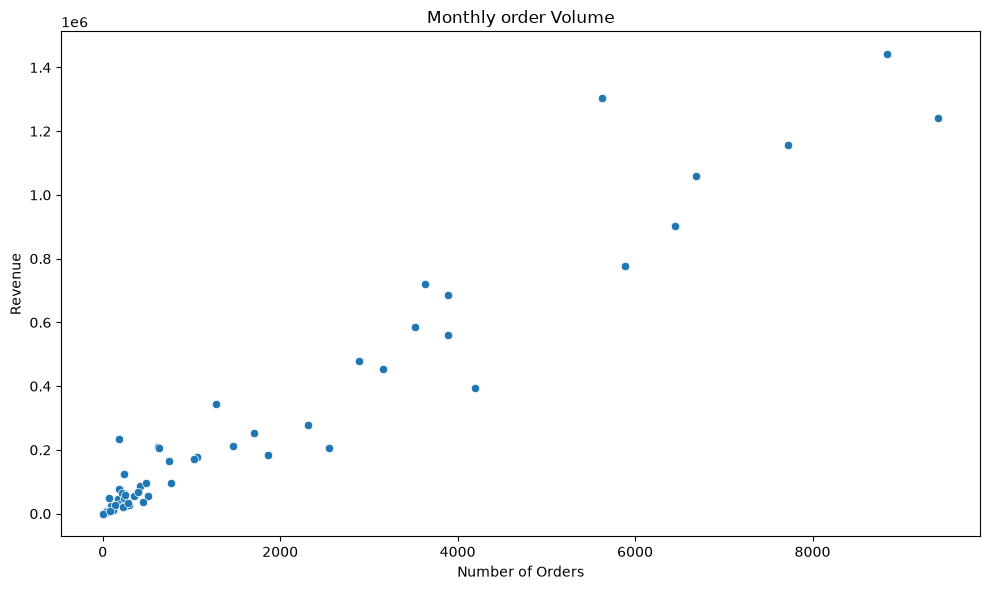

In [243]:
category_compare=category_sales.merge(category_orders,on='category',how='left')

plt.figure(figsize=(10,6))
sns.scatterplot(data=category_compare,x='orders',y='revenue')

plt.title('Monthly order Volume')
plt.xlabel('Number of Orders')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

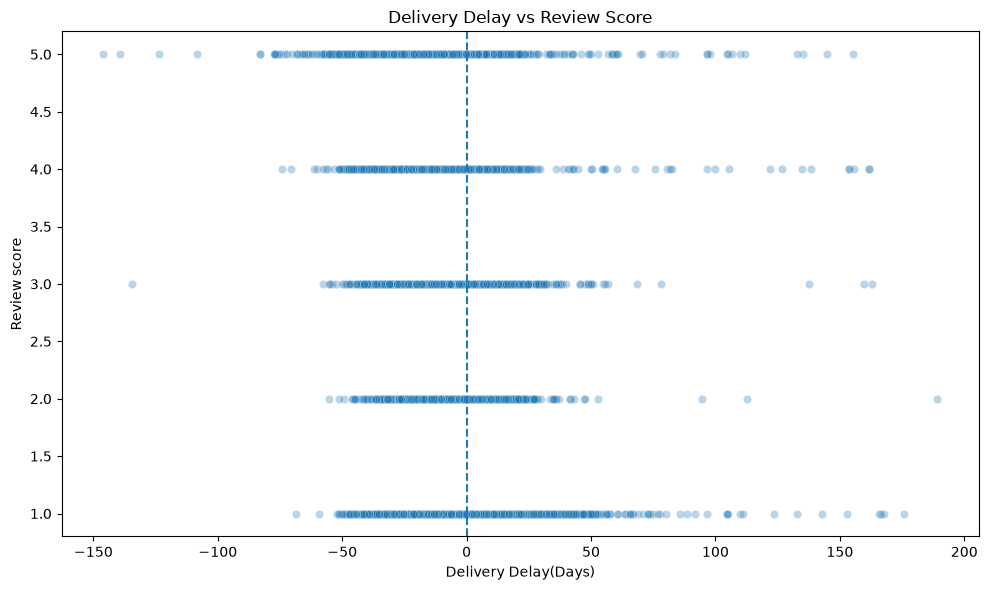

In [244]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=review_delivery,x='delivery_delay_days',y='review_score',alpha=0.3)

plt.axvline(0,linestyle='--')
plt.title('Delivery Delay vs Review Score')
plt.xlabel('Delivery Delay(Days)')
plt.ylabel('Review score')
plt.tight_layout()
plt.show()

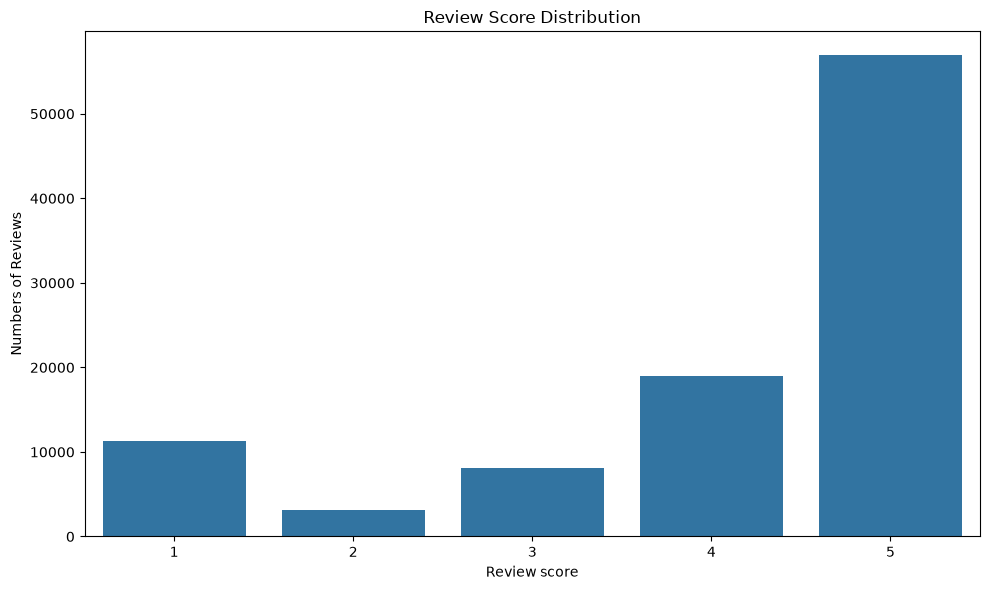

In [245]:
plt.figure(figsize=(10,6))
sns.countplot(data=reviews,x='review_score')

plt.title('Review Score Distribution')
plt.xlabel('Review score')
plt.ylabel('Numbers of Reviews')
plt.tight_layout()
plt.show()

In [246]:
# create KPI summary
kpi_summary = {
    'Total Revenue': total_revenue,
    'Total Orders': total_orders,
    'Average Order Value': overall_aov,
    'Total Customers': total_customers,
    'Total Sellers': total_sellers,
    'Positive Review Rate (%)': 77.14,
    'Freight Cost (%)': 14.21,
    'Repeat Customer Rate (%)': 3.05
}

kpi_summary

{'Total Revenue': np.float64(15843553.24),
 'Total Orders': 98666,
 'Average Order Value': np.float64(160.57763809214927),
 'Total Customers': 95420,
 'Total Sellers': 3095,
 'Positive Review Rate (%)': 77.14,
 'Freight Cost (%)': 14.21,
 'Repeat Customer Rate (%)': 3.05}

In [247]:
sales.to_csv(
    r'C:\Users\user\Desktop\data analysis\ecommerce_analysis\data\sales_final.csv',
    index=False
)

In [248]:
sales.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'total_payment_value', 'item_total',
       'delivery_days', 'delivery_delay_days', 'delivery_status'],
      dtype='str')

In [249]:
sales=sales.merge(reviews,on='order_id',how='left')

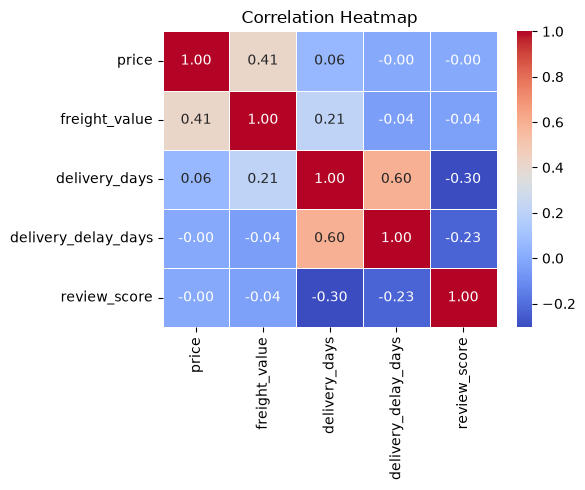

In [251]:
corr_data = sales[
    [
        'price',
        'freight_value',
        'delivery_days',
        'delivery_delay_days',
        'review_score'
    ]
]

corr_matrix = corr_data.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()